In [28]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, ttest_ind, ttest_rel, spearmanr, mannwhitneyu
import scikit_posthocs as sp
from sklearn.metrics import r2_score
import json

In [29]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [30]:
target = 'IDO_counts'
target_col = 'patient_ID'
celltypes = ['DCs', 'Macs/monos', 'HLA-DR+ Macs/monos']

In [31]:
adata2 = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_thresholds_scanorama.h5ad")
adata2 = adata2[adata2.obs.index.isin(adata.obs.index)]
adata.obs[target] = adata2.obs[target].reindex(adata.obs.index)
adata.obs['feature_cells'] =  adata.obs['Phenotype4'].astype(str) + '_' + adata2.obs[target].astype(str)
# Filter for plasma cells and prepare the dataframe
df = adata[(adata.obs['Phenotype4'] == 'PCs')].obs[['distance_to_bone_corrected', 'disease3', target_col, 'feature_cells']]
bins = list(range(0, 301, 20)) #+ list(range(200, 1001, 250)) 
# Bin distances
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)

# Group by disease and distance bins
disease_distance_summary = df.groupby([target_col, 'distance_bin']).apply(
    lambda x: pd.Series({
        'total_cells': len(x),
        'feature_pos_cells': (x['feature_cells'] == 'PCs_1').sum()
    })
)
disease_distance_summary['feature_pos_ratio'] = disease_distance_summary['feature_pos_cells'] / disease_distance_summary['total_cells']
disease_distance_summary.reset_index(inplace=True)
disease_mapping = adata.obs[['disease3', target_col]].drop_duplicates()
disease_mapping = disease_mapping.set_index(target_col)
disease_distance_summary['disease3'] = disease_distance_summary[target_col].map(disease_mapping['disease3'])
summary_stats = disease_distance_summary.groupby(['distance_bin', 'disease3'], observed=True)['feature_pos_ratio'].agg(['mean', 'sem']).reset_index()
summary_stats['distance_bin'] = summary_stats['distance_bin'].astype(str)
summary_stats

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/578673510.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/578673510.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disease_distance_summary = df.groupby([target_col, 'distance_bin']).apply(
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/578673510.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This 

,distance_bin,disease3,mean,sem
0,"(0, 20]",MGUS,0.026248,0.013736
1,"(0, 20]",MM,0.023337,0.005807
2,"(0, 20]",SMM,0.001418,0.001418
3,"(20, 40]",MGUS,0.050096,0.013949
4,"(20, 40]",MM,0.014727,0.003133
5,"(20, 40]",SMM,0.005000,0.005000
6,"(40, 60]",MGUS,0.043947,0.016433
7,"(40, 60]",MM,0.014219,0.002866
8,"(40, 60]",SMM,0.000000,0.000000
9,"(60, 80]",MGUS,0.105004,0.057255


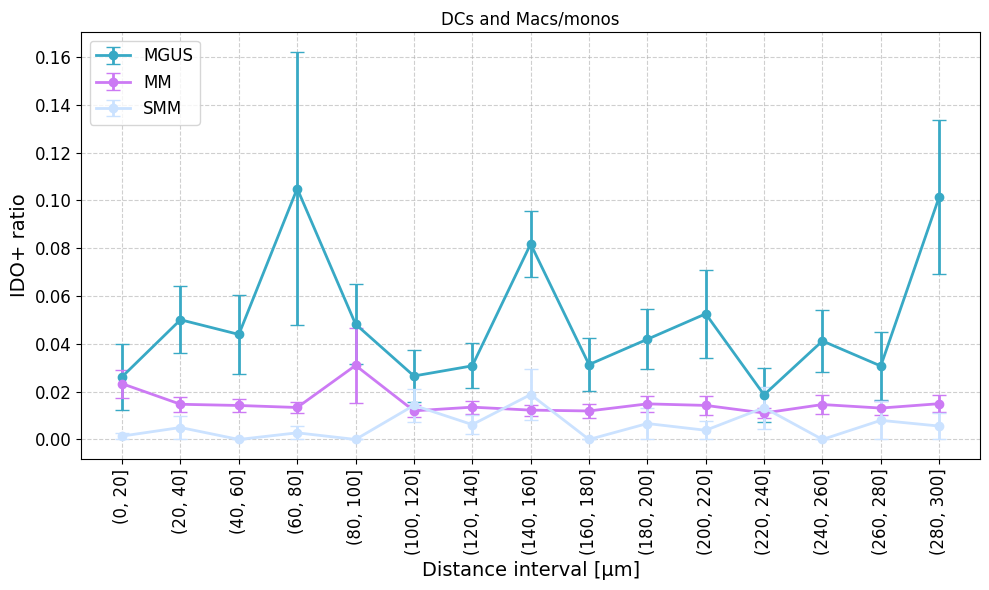

In [34]:
plt.figure(figsize=(10, 6))
plt.style.use('default')
for disease in summary_stats['disease3'].unique():
    subset = summary_stats[summary_stats['disease3'] == disease]
    color = disease3_color_map.get(disease) 
    
    plt.errorbar(
        x=subset['distance_bin'].astype(str),
        y=subset['mean'], 
        yerr=subset['sem'],
        label=disease,
        marker='o', 
        linestyle='-', 
        capsize=5, 
        color=color ,
        linewidth=2,
    )

plt.xticks(rotation=90)
plt.xlabel('Distance interval [µm]', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('IDO+ ratio', fontsize=14)
plt.title('DCs and Macs/monos')
plt.legend(title='', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout() 
plt.savefig(os.path.join(save_path, f"mean_IDO_distance_to_bone.{extension}"))

In [33]:
disease_distance_summary['distance_bin'] = disease_distance_summary['distance_bin'].astype(str)
zero_twenty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(0, 20]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
twenty_forty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(20, 40]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
forty_sixty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(40, 60]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
sixty_eighty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(60, 80]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
stats, pval = ttest_rel(zero_twenty, twenty_forty, nan_policy='omit')
print(f"t-test between (0, 20] and (20, 40]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(twenty_forty, forty_sixty, nan_policy='omit')
print(f"t-test between (20, 40] and (40, 60]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(forty_sixty, sixty_eighty, nan_policy='omit')
print(f"t-test between (40, 60] and (60, 80]: t-stat: {stats:.3f}, p-val: {pval:.4f}")

t-test between (0, 20] and (20, 40]: t-stat: 1.708, p-val: 0.0926
t-test between (20, 40] and (40, 60]: t-stat: 0.181, p-val: 0.8567
t-test between (40, 60] and (60, 80]: t-stat: 0.298, p-val: 0.7668


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/74324954.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/74324954.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disease_distance_summary = df.groupby([target_col, 'distance_bin']).apply(
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_8038/74324954.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This be

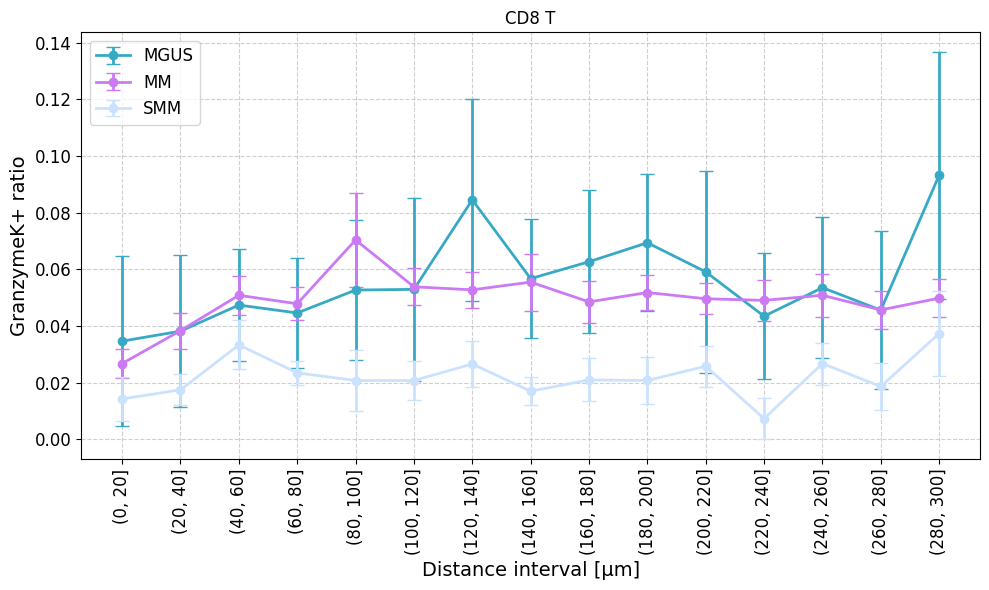

In [35]:
target = 'GranzymeK_counts'
target_col = 'patient_ID'
celltypes = ['CD8 T']
adata2 = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_thresholds_scanorama.h5ad")
adata2 = adata2[adata2.obs.index.isin(adata.obs.index)]
adata.obs[target] = adata2.obs[target].reindex(adata.obs.index)
adata.obs['feature_cells'] =  adata.obs['Phenotype4'].astype(str) + '_' + adata2.obs[target].astype(str)
# Filter for plasma cells and prepare the dataframe
df = adata[(adata.obs['Phenotype4'] == 'PCs')].obs[['distance_to_bone_corrected', 'disease3', target_col, 'feature_cells']]
bins = list(range(0, 301, 20)) #+ list(range(200, 1001, 250)) 
# Bin distances
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], bins=bins)

# Group by disease and distance bins
disease_distance_summary = df.groupby([target_col, 'distance_bin']).apply(
    lambda x: pd.Series({
        'total_cells': len(x),
        'feature_pos_cells': (x['feature_cells'] == 'PCs_1').sum()
    })
)
disease_distance_summary['feature_pos_ratio'] = disease_distance_summary['feature_pos_cells'] / disease_distance_summary['total_cells']
disease_distance_summary.reset_index(inplace=True)
disease_mapping = adata.obs[['disease3', target_col]].drop_duplicates()
disease_mapping = disease_mapping.set_index(target_col)
disease_distance_summary['disease3'] = disease_distance_summary[target_col].map(disease_mapping['disease3'])
summary_stats = disease_distance_summary.groupby(['distance_bin', 'disease3'], observed=True)['feature_pos_ratio'].agg(['mean', 'sem']).reset_index()
summary_stats['distance_bin'] = summary_stats['distance_bin'].astype(str)
plt.figure(figsize=(10, 6))
plt.style.use('default')
for disease in summary_stats['disease3'].unique():
    subset = summary_stats[summary_stats['disease3'] == disease]
    color = disease3_color_map.get(disease) 
    
    plt.errorbar(
        x=subset['distance_bin'].astype(str),
        y=subset['mean'], 
        yerr=subset['sem'],
        label=disease,
        marker='o', 
        linestyle='-', 
        capsize=5, 
        color=color ,
        linewidth=2,
    )

plt.xticks(rotation=90)
plt.xlabel('Distance interval [µm]', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('GranzymeK+ ratio', fontsize=14)
plt.title('CD8 T')
plt.legend(title='', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout() 
plt.savefig(os.path.join(save_path, f"mean_GranzymeK_distance_to_bone.{extension}"))

In [36]:
disease_distance_summary['distance_bin'] = disease_distance_summary['distance_bin'].astype(str)
zero_twenty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(0, 20]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
twenty_forty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(20, 40]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
forty_sixty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(40, 60]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
sixty_eighty = disease_distance_summary[(disease_distance_summary['distance_bin'] == '(60, 80]') & (disease_distance_summary['disease3'] == 'MM')]['feature_pos_ratio'].values
stats, pval = ttest_rel(zero_twenty, twenty_forty, nan_policy='omit')
print(f"t-test between (0, 20] and (20, 40]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(twenty_forty, forty_sixty, nan_policy='omit')
print(f"t-test between (20, 40] and (40, 60]: t-stat: {stats:.3f}, p-val: {pval:.4f}")
stats, pval = ttest_rel(forty_sixty, sixty_eighty, nan_policy='omit')
print(f"t-test between (40, 60] and (60, 80]: t-stat: {stats:.3f}, p-val: {pval:.4f}")

t-test between (0, 20] and (20, 40]: t-stat: -2.252, p-val: 0.0278
t-test between (20, 40] and (40, 60]: t-stat: -3.354, p-val: 0.0014
t-test between (40, 60] and (60, 80]: t-stat: 0.811, p-val: 0.4202
